# Instalação das bibliotecas

In [ ]:
# Instalando bibliotecas
!pip install prophet
!pip install -U mlforecast
!pip install -U utilsforecast
!pip show utilsforecast matplotlib pandas
!pip install statsmodels


In [2]:
#Carrega bibliotecas iniciais
import numpy as np
import pandas as pd
import seaborn as sns
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from utilsforecast.losses import mae, mape,rmse,smape
from utilsforecast.evaluation import evaluate
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from google.colab import files
import seaborn as sns
import lightgbm as lgb
from sklearn.base import BaseEstimator
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mlforecast.utils import PredictionIntervals
sns.set()

In [3]:
%matplotlib inline

In [4]:
pd.plotting.register_matplotlib_converters()
plt.rc("figure", figsize=(10, 8))
plt.rc("font", size=10)

Fazer o upload do arquivo:


> base_de_dados_etanol.csv



In [5]:
uploaded = files.upload()

Saving base_de_dados_etanol.csv to base_de_dados_etanol.csv


# Dados

Utilizei os dados do CEPEA USP ESALQ - Preço do etanol (R$). Os valores estão em peridiocidade mensal, de Jan/2015 até Jun/2025.

Transformação dos dados

In [5]:
# Função para carregar os dados do etanol
def carregar_dados_etanol():

    # Lista para armazenar dataframes (mantendo a lógica do código original)
    lista_dataframes = []

    # Lê o arquivo CSV
    df = pd.read_csv(
        "base_de_dados_etanol.csv",
        encoding='latin-1',
        sep=';'
    )

    # Converter preço para número
    df["À vista R$"] = df["À vista R$"].str.replace(",", ".").astype(float)

    # Converter data
    df["Data"] = pd.to_datetime(df["Data"], format="%m/%Y")

    # Ordenar série temporal
    df = df.sort_values("Data")

    # Adiciona à lista de dataframes
    lista_dataframes.append(df)

    # Concatena (mesmo que tenha apenas um arquivo, mantém o padrão do código original)
    arquivo_etanol = pd.concat(lista_dataframes, ignore_index=True)

    # Série temporal
    data = arquivo_etanol["À vista R$"].values

    return arquivo_etanol, data

In [6]:
# Busca os dados de 2014 até 2024
start_year = 2015
end_year = 2025
# Carrega os dados do etanol
df_etanol, data = carregar_dados_etanol()

In [7]:
# Dicionário para armazenar os DataFrames
dfs_series = {}

# Intervalo desejado
inicio = '2015-01-01'
fim = '2025-06-01'

# Cria dataframe no formato padrão de séries temporais
df = (
    df_etanol
    [['Data', 'À vista R$']]
    .rename(columns={
        'Data': 'ds',
        'À vista R$': 'y'
    })
)

# Criar identificador da série
df['unique_id'] = 'etanol'

# Define índice temporal
df = df.set_index('ds')

# Interpolação de possíveis valores faltantes
df['y'] = df['y'].interpolate(method='time')

# Filtrar intervalo de datas
df = df.query("index >= @inicio and index <= @fim")

# Resetar índice
df.reset_index(inplace=True)

# Garantir datetime
df['ds'] = pd.to_datetime(df['ds'])

# Remover duplicatas
df = df.drop_duplicates(subset=['unique_id', 'ds'])

# Salvar no dicionário
dfs_series['etanol'] = df

In [8]:
#Olhando o data frame
df

,ds,y,unique_id
0,2015-01-01,1.4826,etanol
1,2015-02-01,1.5080,etanol
2,2015-03-01,1.4176,etanol
3,2015-04-01,1.4151,etanol
4,2015-05-01,1.4067,etanol
...,...,...,...
121,2025-02-01,3.2066,etanol
122,2025-03-01,3.3520,etanol
123,2025-04-01,3.1328,etanol
124,2025-05-01,3.5664,etanol


Plotando o gráfico do histórico de preços

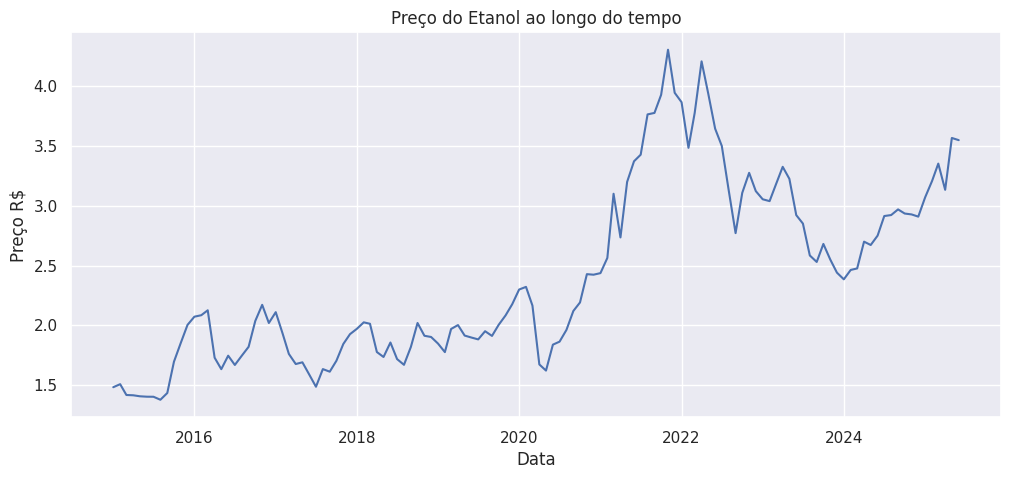

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df_etanol["Data"], df_etanol["À vista R$"])

plt.title("Preço do Etanol ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Preço R$")
plt.grid(True)

plt.show()

Dividindo a série em treinamento (80%) e teste (20%)

In [10]:
# Usar o dataframe para a análise
df_analise = df_etanol.copy()

# Garantir que a coluna de data está em datetime
df_analise["Data"] = pd.to_datetime(df_analise["Data"])

# Ordenar pela data
df_analise = df_analise.sort_values("Data")

# Calcula o índice de corte (80%)
corte_idx = int(len(df_analise) * 0.8)

# Divide treino e teste
df_treino = df_analise.iloc[:corte_idx]
df_teste = df_analise.iloc[corte_idx:]

# Verifica os tamanhos
print(f"Tamanho treino: {len(df_treino)}")
print(f"Tamanho teste: {len(df_teste)}")

# Mostra as datas
print("Treino:", df_treino["Data"].min(), "até", df_treino["Data"].max())
print("Teste:", df_teste["Data"].min(), "até", df_teste["Data"].max())

Tamanho treino: 100
Tamanho teste: 26
Treino: 2015-01-01 00:00:00 até 2023-04-01 00:00:00
Teste: 2023-05-01 00:00:00 até 2025-06-01 00:00:00


# Gerando os modelos de Machine Learning

In [11]:
# cria modelo ingenuo
class Naive(BaseEstimator):
    def fit(self, x, y):
        return self

    def predict(self, X):
        return X['lag1']

# Dicionário de modelos
models = {
    'naive': Naive(),
    'lgbm': lgb.LGBMRegressor(verbosity=-1),
    'lasso': Lasso(),
    'lin_reg': LinearRegression(),
    'ridge': Ridge(),
    'knn': KNeighborsRegressor(),
    'mlp': MLPRegressor(),
    'rf': RandomForestRegressor()
}

# Define os lags
lags = [1, 12]

# Instancia objeto de MLForecast
mlf = MLForecast(
    models=models,
    freq='MS', # Alterado de 'M' para 'MS' para corresponder à frequência de início do mês dos dados
    target_transforms=[Differences([1, 12])],
    lags=lags,
    lag_transforms={
        1: [ExpandingMean()],
        12: [RollingMean(window_size=12)],
    },
    date_features=['month']
)

Aplicação da Validação Cruzada
1.   Renomeando colunas
2.   Remoção de duplicatas
3.   Ordenando por Datas



In [12]:
# Garante que a coluna 'ds' está presente como coluna (não como índice)
if df_treino.index.name == 'Data':
    df_treino = df_treino.reset_index()

# Renomeia as colunas para o formato esperado pelo mlforecast
df_treino = df_treino.rename(columns={'Data': 'ds', 'À vista R$': 'y'})

# Adiciona a coluna 'unique_id'
df_treino['unique_id'] = 'etanol'

# Remove duplicatas (se houver)
df_treino = df_treino.drop_duplicates(subset=['unique_id', 'ds'])

# Ordena pela data
df_treino = df_treino.sort_values(by='ds')

# Aplica validação cruzada
crossvalidation_df = mlf.cross_validation(
    df=df_treino,
    h=24,
    n_windows=2,
    refit=False,
    static_features=[]
)

crossvalidation_df

,unique_id,ds,cutoff,y,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf
0,etanol,2019-05-01,2019-04-01,1.9144,2.2294,1.980525,1.980525,2.007930,1.992720,2.01020,1.832296,1.869708
1,etanol,2019-06-01,2019-04-01,1.8976,2.6192,2.121450,2.121450,2.006503,2.085613,2.08794,1.795734,1.895304
2,etanol,2019-07-01,2019-04-01,1.8824,2.7494,2.002775,2.002775,1.997545,1.961200,1.97064,1.430931,1.689242
3,etanol,2019-08-01,2019-04-01,1.9508,2.9703,1.974800,1.974800,2.150268,1.947246,1.97696,1.094659,1.835683
4,etanol,2019-09-01,2019-04-01,1.9114,3.3886,2.144225,2.144225,2.205674,2.048330,2.08646,0.957772,1.908888
5,etanol,2019-10-01,2019-04-01,2.0041,3.8576,2.364350,2.364350,2.425765,2.203883,2.23572,0.832566,2.075456
6,etanol,2019-11-01,2019-04-01,2.0827,4.0196,2.277475,2.277475,2.602839,2.111695,2.07798,0.323380,2.127805
7,etanol,2019-12-01,2019-04-01,2.1765,4.2782,2.287200,2.287200,2.630024,2.074287,2.01684,-0.117842,2.258813
8,etanol,2020-01-01,2019-04-01,2.2993,4.4922,2.252325,2.252325,2.396577,2.106974,1.99556,-0.243414,2.362004
9,etanol,2020-02-01,2019-04-01,2.3214,4.6893,2.200550,2.200550,2.130951,2.115223,1.94788,-0.379098,2.440821


Agora plotando cada modelos e a janela(fold do CV) para verificar os seus respectivos comportamentos.

In [13]:
def plot_cv(df, df_cv, uid, last_n=24*14, models=[]):
    cutoffs = df_cv.query('unique_id == @uid')['cutoff'].unique()

    fig, ax = plt.subplots(nrows=len(cutoffs), ncols=1, figsize=(14, 14),
                           gridspec_kw=dict(hspace=0.8))

    # tratar caso 1 subplot
    if len(cutoffs) == 1:
        axes = [ax]
    else:
        axes = ax.flat

    for cutoff, axi in zip(cutoffs, axes):
        max_date = df_cv.query('(unique_id == @uid) & (cutoff == @cutoff)')['ds'].max()

        # Resetar o índice para garantir que 'ds' seja uma coluna antes de set_index
        df_plot = df.reset_index()

        df_plot.query('unique_id == @uid and ds <= @max_date').set_index('ds')['y'].plot(ax=axi, title=uid)

        for m in models:
            df_cv.query('(unique_id == @uid) & (cutoff == @cutoff)').set_index('ds')[m].plot(ax=axi, label=m)

        axi.legend()

    plt.show()

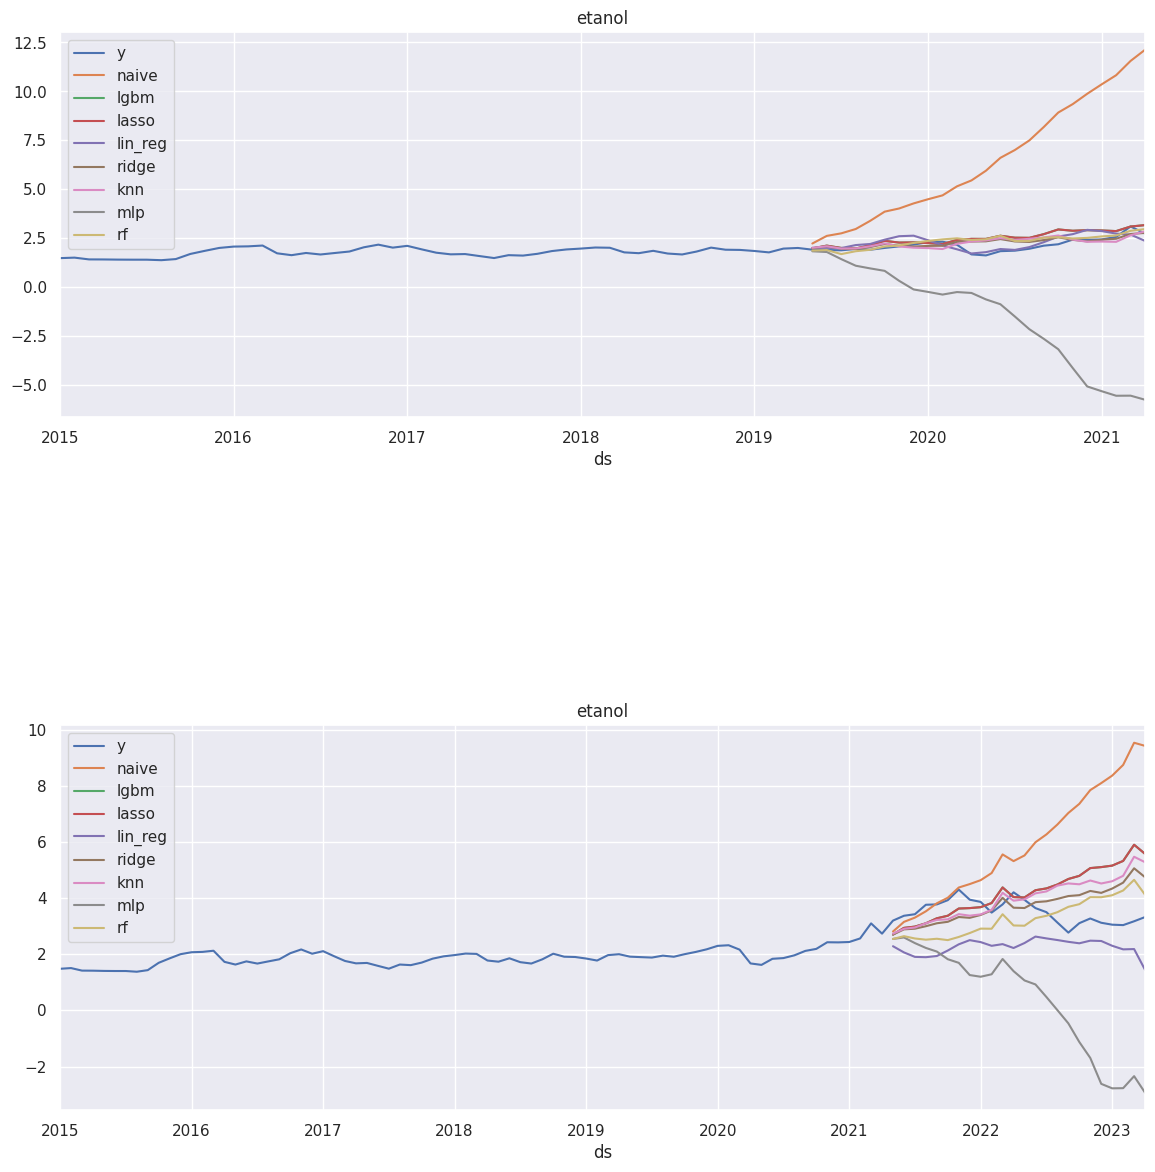

In [14]:
#Plota
plot_cv(df_treino,crossvalidation_df, 'etanol', models=models)

# Métricas de Acurácia
Examina visualmente as previsões pode nos dar alguma ideia de como o modelo está se comportando, mas para avaliar o desempenho, precisamos avaliá-las por meio de métricas. Para isso, usei a biblioteca utilsforecast, que contém muitas métricas úteis e uma função de avaliação.

In [15]:
#métricas utilizadas para a avaliação
metrics=[
    mae,
    mape,
    rmse,
    smape
]

#Função de avaliação da validade cruzada
def evaluate_crossvalidation(crossvalidation_df, metrics,models):
    evaluations = []
    for c in crossvalidation_df['cutoff'].unique():
        df_cv = crossvalidation_df.query('cutoff == @c')
        evaluation = evaluate(
            df = df_cv,
            metrics = metrics,
            models = list(models.keys()),
        )
        evaluations.append(evaluation)
    evaluations = pd.concat(evaluations,ignore_index=True).drop(columns='unique_id')
    evaluations = evaluations.groupby('metric').mean()
    return evaluations.style.background_gradient(cmap='RdYlGn_r',axis=1)

In [16]:
#Verifica as métricas
evaluate_crossvalidation(crossvalidation_df, metrics, models)

,cutoff,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf
metric,,,,,,,,,
mae,2020-03-31 12:00:00,3.356898,0.706252,0.706252,0.742555,0.505707,0.599565,3.394022,0.574671
mape,2020-03-31 12:00:00,1.337443,0.252170,0.252170,0.228151,0.175216,0.209756,1.257949,0.191888
rmse,2020-03-31 12:00:00,4.183600,0.884202,0.884202,0.808877,0.605708,0.732257,4.068577,0.663323
smape,2020-03-31 12:00:00,0.335070,0.105459,0.105459,0.133390,0.079892,0.092161,0.707915,0.094523


# Conjunto de teste
Agora vou comparar os dados previsto do conjunto de treinamento no conjunto de teste, de forma a compreender qual modelo melhor realizou a previsão. Adicionei intervalos de confiança para cada previsão.

In [17]:
# Realiza o ajuste com intervalos
mlf.fit(
    df=df_treino,
    prediction_intervals=PredictionIntervals(n_windows=2, h=24)
)

#Define os intervalo e a realiza a previsão
levels = [90,95] #Intervalo de confiança
forecasts = mlf.predict(24,level=levels)
forecasts.head()

,unique_id,ds,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf,...,knn-hi-90,knn-hi-95,mlp-lo-95,mlp-lo-90,mlp-hi-90,mlp-hi-95,rf-lo-95,rf-lo-90,rf-hi-90,rf-hi-95
0,etanol,2023-05-01,2.7744,3.166325,3.043288,3.524603,3.394015,3.19044,3.015118,3.327465,...,3.601080,3.628860,2.445039,2.487341,3.542895,3.585197,2.713313,2.761842,3.893088,3.941617
1,etanol,2023-06-01,2.2002,2.959319,2.737975,3.559472,3.330257,2.85950,2.655264,3.235136,...,3.283267,3.303864,2.031766,2.081349,3.229179,3.278762,2.549455,2.601768,3.868504,3.920817
2,etanol,2023-07-01,1.7745,3.030998,2.581163,3.602786,3.290859,2.70630,2.404636,3.203409,...,3.122062,3.150961,1.622591,1.665280,3.143991,3.186680,2.380022,2.435977,3.970841,4.026796
3,etanol,2023-08-01,1.1233,2.697155,2.198850,3.734001,3.256676,2.23278,1.977497,3.052170,...,2.795953,2.843337,0.832439,0.884243,3.070751,3.122555,1.883075,1.970724,4.133616,4.221265
4,etanol,2023-09-01,0.4834,2.509556,1.827838,3.692418,3.084800,1.80668,1.518189,2.947482,...,2.302428,2.330724,0.388742,0.443890,2.592488,2.647635,1.804469,1.897135,3.997829,4.090495


In [18]:
# Preparar df_teste para o merge
df_teste_prepared = df_teste.rename(columns={'Data': 'ds', 'À vista R$': 'y'})
df_teste_prepared['unique_id'] = 'etanol'

# Junta os dados do conjunto de teste e a previsão
test = df_teste_prepared.merge(forecasts, on=['unique_id', 'ds'], how='left')
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 43 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ds             26 non-null     datetime64[ns]
 1   y              26 non-null     float64       
 2   unique_id      26 non-null     object        
 3   naive          24 non-null     float64       
 4   lgbm           24 non-null     float64       
 5   lasso          24 non-null     float64       
 6   lin_reg        24 non-null     float64       
 7   ridge          24 non-null     float64       
 8   knn            24 non-null     float64       
 9   mlp            24 non-null     float64       
 10  rf             24 non-null     float64       
 11  naive-lo-95    24 non-null     float64       
 12  naive-lo-90    24 non-null     float64       
 13  naive-hi-90    24 non-null     float64       
 14  naive-hi-95    24 non-null     float64       
 15  lgbm-lo-95     24 non-nul

,ds,y,unique_id,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,...,knn-hi-90,knn-hi-95,mlp-lo-95,mlp-lo-90,mlp-hi-90,mlp-hi-95,rf-lo-95,rf-lo-90,rf-hi-90,rf-hi-95
0,2023-05-01,3.2248,etanol,2.7744,3.166325,3.043288,3.524603,3.394015,3.19044,3.015118,...,3.601080,3.628860,2.445039,2.487341,3.542895,3.585197,2.713313,2.761842,3.893088,3.941617
1,2023-06-01,2.9213,etanol,2.2002,2.959319,2.737975,3.559472,3.330257,2.85950,2.655264,...,3.283267,3.303864,2.031766,2.081349,3.229179,3.278762,2.549455,2.601768,3.868504,3.920817
2,2023-07-01,2.8505,etanol,1.7745,3.030998,2.581163,3.602786,3.290859,2.70630,2.404636,...,3.122062,3.150961,1.622591,1.665280,3.143991,3.186680,2.380022,2.435977,3.970841,4.026796
3,2023-08-01,2.5840,etanol,1.1233,2.697155,2.198850,3.734001,3.256676,2.23278,1.977497,...,2.795953,2.843337,0.832439,0.884243,3.070751,3.122555,1.883075,1.970724,4.133616,4.221265
4,2023-09-01,2.5298,etanol,0.4834,2.509556,1.827838,3.692418,3.084800,1.80668,1.518189,...,2.302428,2.330724,0.388742,0.443890,2.592488,2.647635,1.804469,1.897135,3.997829,4.090495


In [19]:
# Avalia as métricas de erros
evaluate(
    df=test,
    metrics=metrics,
    models=list(models.keys())
).style.background_gradient(cmap='RdYlGn_r',axis=1)

,unique_id,metric,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf
0,etanol,mae,5.309717,0.404659,1.074739,1.375606,0.531189,0.963325,2.573844,0.441506
1,etanol,mape,1.823919,0.138786,0.366119,0.504473,0.199716,0.327598,0.880507,0.164070
2,etanol,rmse,6.445567,0.522663,1.343594,1.463213,0.623911,1.252340,3.192649,0.518719
3,etanol,smape,0.765432,0.070794,0.236263,0.180629,0.080825,0.208800,0.544611,0.069975


In [20]:
# Avaliação
df_resultado = evaluate(
    df=test,
    metrics=metrics,
    models=list(models.keys())
)

# Caminho local (mesma pasta do notebook)
caminho = 'avaliacao_modelos.csv'

# Exportar
df_resultado.to_csv(caminho, index=False)

print("Arquivo salvo como:", caminho)

Arquivo salvo como: avaliacao_modelos.csv


Construindo as métricas da tabela acima, manualmente. Para assim ter os números arredondados com 4 casas decimais

Arquivo salvo como: avaliacao_modelos.csv


/tmp/ipykernel_7174/748676905.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_cols, rotation=45)
/tmp/ipykernel_7174/748676905.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_cols, rotation=45)
/tmp/ipykernel_7174/748676905.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_cols, rotation=45)
/tmp/ipykernel_7174/748676905.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_cols, rotation=45)


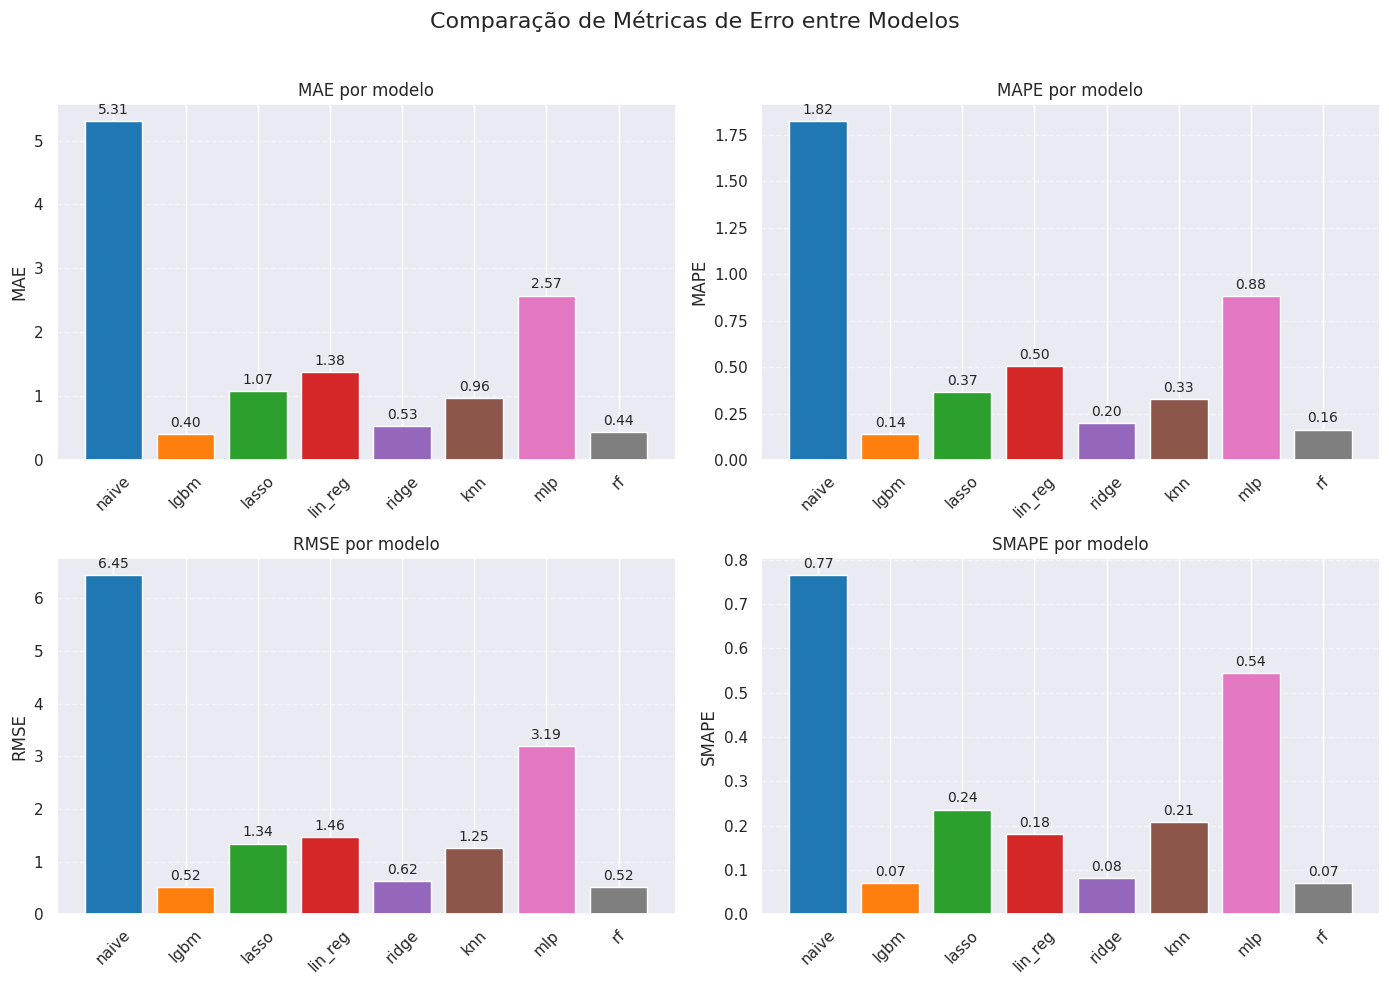

In [31]:
# Criação do DataFrame
df_metrics = pd.DataFrame(
    [
        ['Etanol', 'mae', 5.3097, 0.4046, 1.0747, 1.3756, 0.5311, 0.9633, 2.5738, 0.4415],
        ['Etanol', 'mape', 1.8239, 0.1387, 0.3661, 0.5044, 0.1997, 0.3275, 0.8805, 0.1640],
        ['Etanol', 'rmse', 6.4455, 0.5226, 1.3435, 1.4632, 0.6239, 1.2523, 3.1926, 0.5187],
        ['Etanol', 'smape', 0.7654, 0.0707, 0.2362, 0.1806, 0.0808, 0.2088, 0.5446, 0.0699],
    ],
    columns=[
        'unique_id', 'metric', 'naive', 'lgbm', 'lasso', 'lin_reg', 'ridge', 'knn', 'mlp', 'rf'
    ]
)

# Caminho local
caminho = 'avaliacao_modelos.csv'

# Exportar CSV
df_metrics.to_csv(caminho, index=False)

print("Arquivo salvo como:", caminho)

# Suponha que a tabela de métricas esteja no DataFrame 'df_metrics'
# E que ele tenha as colunas: ['unique_id', 'metric', 'naive', 'lgbm', ..., 'rf']

# Filtra só as colunas de modelos
model_cols = ['naive', 'lgbm', 'lasso', 'lin_reg', 'ridge', 'knn', 'mlp', 'rf']

# Define cores padrão para os modelos
cores = plt.cm.tab10.colors[:len(model_cols)]

# Cria uma figura com subplots por métrica
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Lista de métricas na ordem esperada
metricas = ['mae', 'mape', 'rmse', 'smape']

for i, metrica in enumerate(metricas):
    ax = axes[i]

    # Seleciona a linha da métrica
    linha = df_metrics[df_metrics['metric'] == metrica]

    # Extrai os valores dos modelos
    valores = linha[model_cols].values.flatten()

    # Cria o gráfico de barras
    bars = ax.bar(model_cols, valores, color=cores)
    #ax.bar(model_cols, valores, color=cores)
    ax.set_title(f'{metrica.upper()} por modelo')
    ax.set_ylabel(metrica.upper())
    ax.set_xticklabels(model_cols, rotation=45)
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Comparação de Métricas de Erro entre Modelos', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Plotando os modelos finais

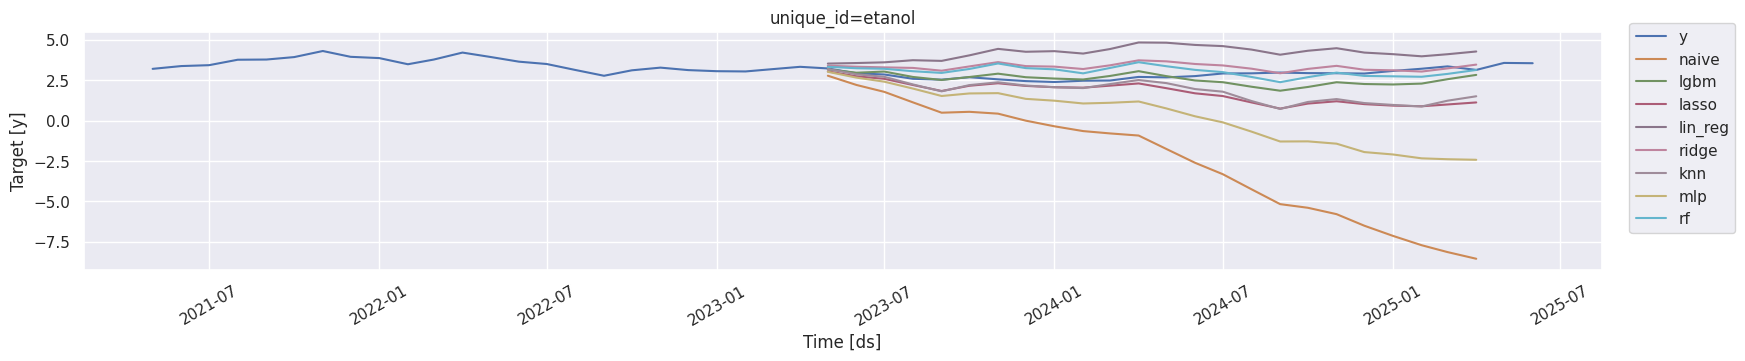

In [32]:
plot_series(
    df_treino,
    test,
    models=list(models.keys()),
    plot_random=False,
    level=None, #antes estava levels no lugar de None
    max_insample_length=24
)


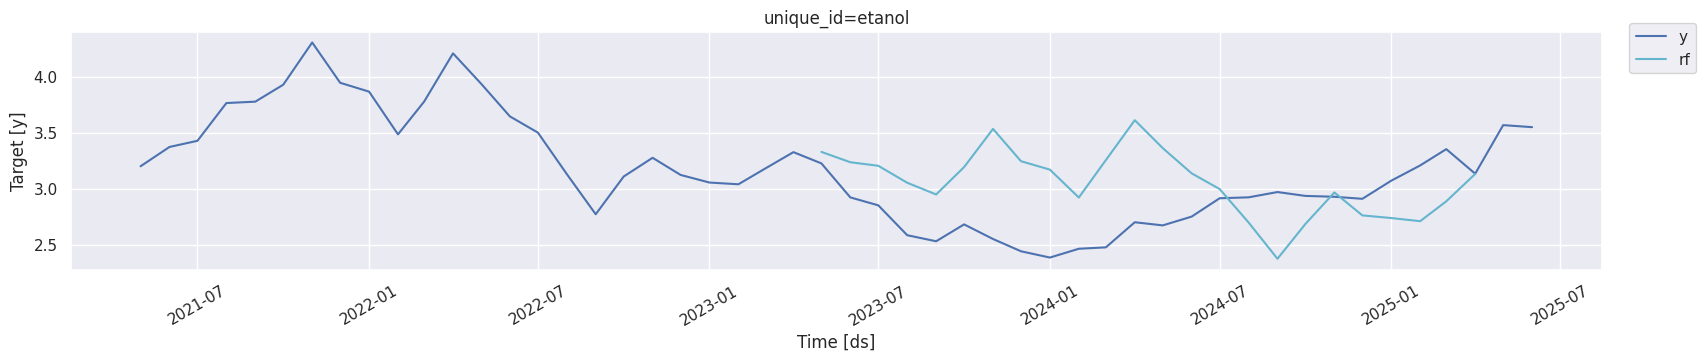

In [33]:
#Plotando o modelo Random Forest com melhores valores de acurácia
plot_series(
    df_treino,
    test,
    models=['rf'],
    plot_random=False,
    level=None, #antes estava levels no lugar de None
    max_insample_length=24
)


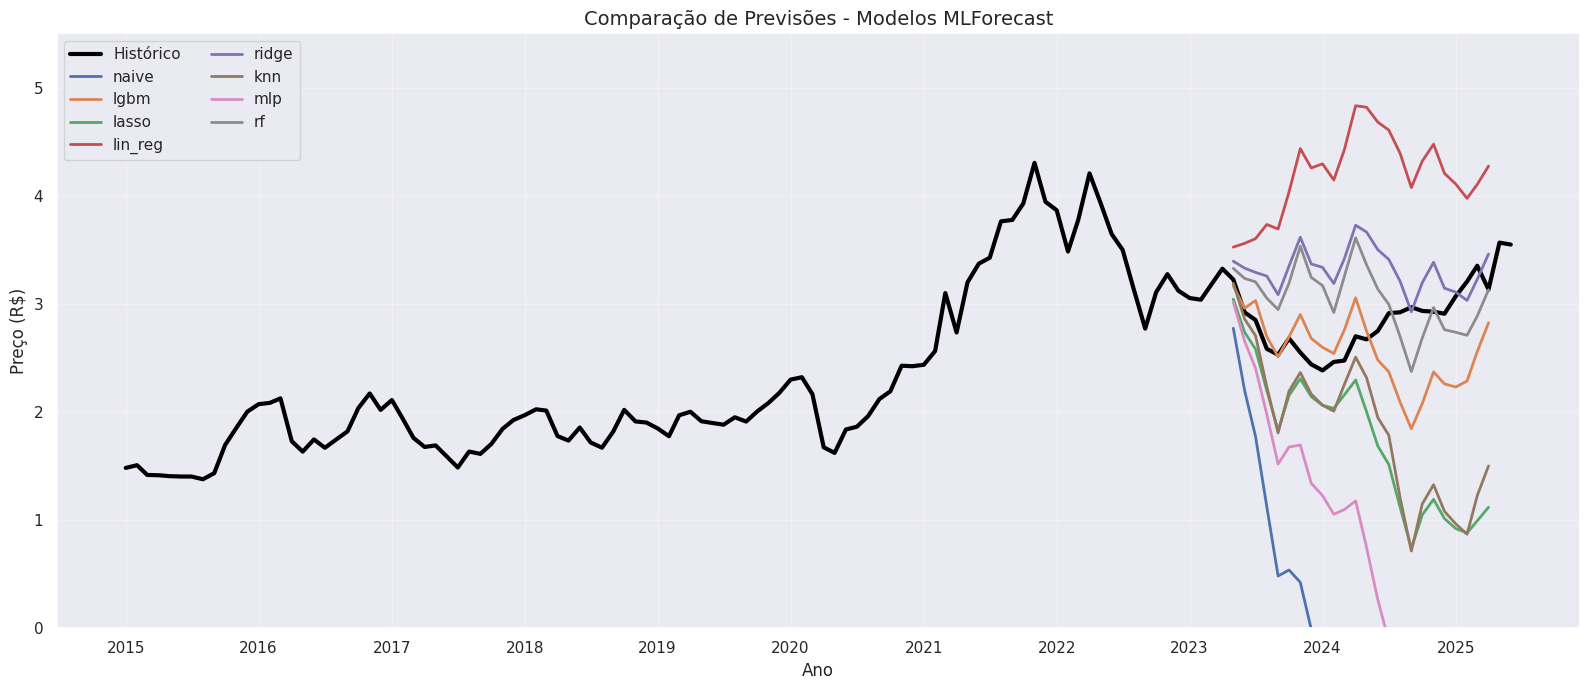

In [27]:
# =========================
# DADOS HISTÓRICOS
# =========================

datas_hist = df["ds"]
valores_hist = df["y"]

# =========================
# PREVISÕES
# =========================

datas_prev = forecasts["ds"]

# lista de modelos (todas as colunas exceto id e data)
modelos = [
    col for col in forecasts.columns
    if col not in ["unique_id", "ds"]
    and "-lo-" not in col
    and "-hi-" not in col
]

# =========================
# PLOT
# =========================

plt.figure(figsize=(16,7))

# Histórico
plt.plot(datas_hist, valores_hist,
         label="Histórico", linewidth=3, color='black')

# Plot de cada modelo
for modelo in modelos:
    plt.plot(datas_prev, forecasts[modelo],
             linestyle='-', linewidth=2, label=modelo)

# Linha separadora
#plt.axvline(x=datas_hist.max(), color='black', linestyle='--', linewidth=1.5)

# Formatação eixo X
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Comparação de Previsões - Modelos MLForecast", fontsize=14)
plt.xlabel("Ano")
plt.ylabel("Preço (R$)")

plt.ylim(0)
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

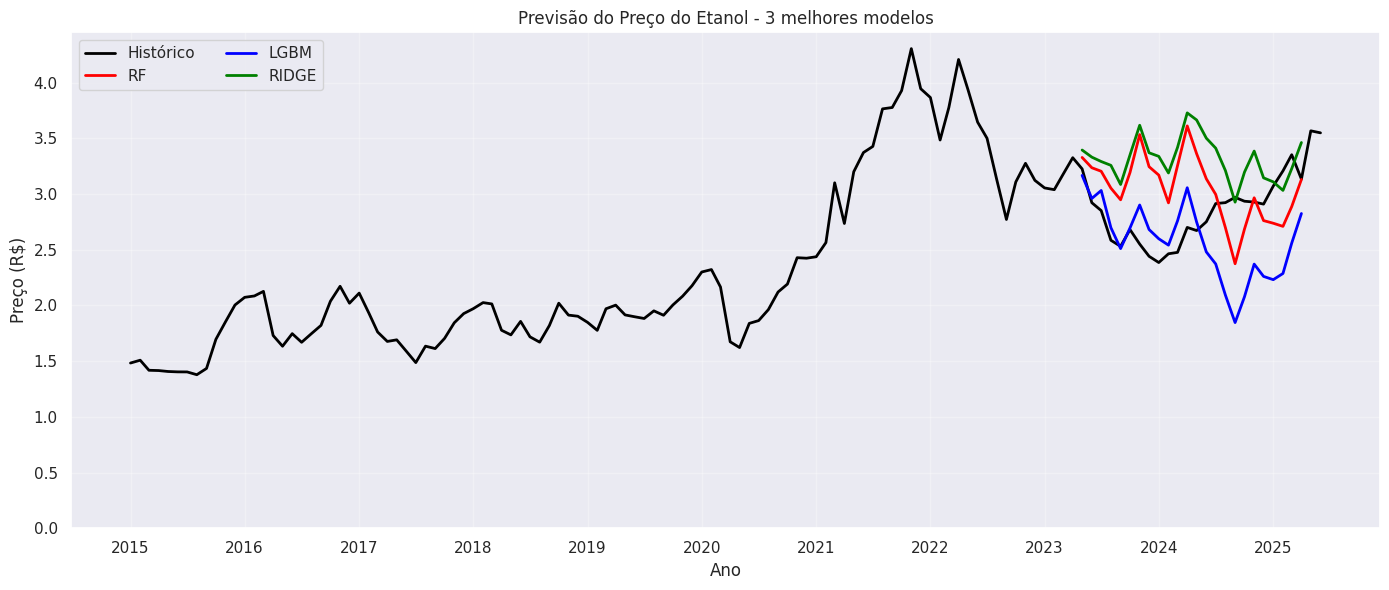

In [26]:
# Histórico
plt.figure(figsize=(14,6))
plt.plot(df["ds"], df["y"], label="Histórico", linewidth=2,color='black')

cores = {
    'rf': 'red',
    'lgbm': 'blue',
    'ridge': 'green'
}

top_models = ['rf', 'lgbm', 'ridge'] # Define top_models here

for modelo in top_models:
    plt.plot(forecasts["ds"], forecasts[modelo], # Corrected 'forecast' to 'forecasts'
             linestyle='-',
             linewidth=2,
             color=cores[modelo],
             label=modelo.upper())

# Formatação eixo X
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Previsão do Preço do Etanol - 3 melhores modelos")
plt.xlabel("Ano")
plt.ylabel("Preço (R$)")

plt.ylim(0)

plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()